# Conditional Probability, Independence, and Bayes' Theorem

## Learning Objectives

By the end of this notebook you will be able to:

1. Compute **conditional probabilities** $P(A|B)$ and interpret them as "shrinking the sample space".
2. Define **independence** and test whether two events are independent.
3. Apply the **multiplication rule** for joint probabilities.
4. State and apply **Bayes' theorem** to invert conditional probabilities.
5. Recognise the **base-rate fallacy** in real-world diagnostic problems.

## Prerequisites

- [01_sample_spaces.ipynb](01_sample_spaces.ipynb) — sample spaces, events, axioms
- [02_combinatorics.ipynb](02_combinatorics.ipynb) — counting techniques

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr.replace(r"\\", ""), **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. Conditional Probability — Shrinking the Sample Space

So far we have computed probabilities when we know nothing. But in practice we often have **partial information**: the patient tested positive, it rained this morning, the first card was an Ace. How does knowing that one event occurred change the probability of another?

> **Definition 3.1 (Conditional probability).** For events $A$ and $B$ with $P(B) > 0$, the *conditional probability of $A$ given $B$* is
>
> $$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

**Intuition:** When we learn that $B$ has occurred, $B$ becomes our new "universe". We discard everything outside $B$ and renormalise what remains. The probability of $A$ is now the fraction of $B$ that also belongs to $A$.

### Example: cards

Draw one card from a standard 52-card deck. Let:
- $A$ = "card is an Ace" → $P(A) = 4/52 = 1/13$
- $B$ = "card is a heart" → $P(B) = 13/52 = 1/4$
- $A \cap B$ = "card is the Ace of hearts" → $P(A \cap B) = 1/52$

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)} = \frac{1/52}{13/52} = \frac{1}{13}$$

Knowing the card is a heart didn't change the probability of it being an Ace! (This is because $A$ and $B$ are independent — we'll formalise this shortly.)

### Example: two dice

Roll two fair dice. Let:
- $A$ = "sum is 8"
- $B$ = "first die shows 3"

$\Omega$ has 36 outcomes. $B = \{(3,1), (3,2), \dots, (3,6)\}$ so $P(B) = 6/36 = 1/6$. 

$A \cap B = \{(3,5)\}$ (the only way to get sum 8 with first die 3), so $P(A \cap B) = 1/36$.

$$P(A \mid B) = \frac{1/36}{1/6} = \frac{1}{6}$$

Compare with the unconditional: $P(A) = 5/36 \approx 0.139$. Knowing the first die is 3 changes the probability from $5/36$ to $1/6$.

In [ ]:
# Verify the two-dice example with a direct count
omega = [(i, j) for i in range(1, 7) for j in range(1, 7)]

A = {(i, j) for (i, j) in omega if i + j == 8}
B = {(i, j) for (i, j) in omega if i == 3}
A_and_B = A & B

print(f"A (sum=8):   {sorted(A)}   |A| = {len(A)}")
print(f"B (die1=3):  {sorted(B)}   |B| = {len(B)}")
print(f"A ∩ B:       {sorted(A_and_B)}")
print(f"\nP(A)     = {len(A)}/36 = {len(A) / 36:.4f}")
print(f"P(A|B)   = |A∩B|/|B| = {len(A_and_B)}/{len(B)} = {len(A_and_B) / len(B):.4f}")

A (sum=8):   [(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)]   |A| = 5
B (die1=3):  [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]   |B| = 6
A ∩ B:       [(3, 5)]

P(A)     = 5/36 = 0.1389
P(A|B)   = |A∩B|/|B| = 1/6 = 0.1667


### Visualising conditional probability

The animation below shows conditional probability as literally **shrinking the sample space**. When we condition on $B$, the "universe" contracts from $\Omega$ to $B$, and the probability of $A$ becomes the proportion of $B$ that overlaps with $A$.

In [4]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

Manim Community v0.18.1

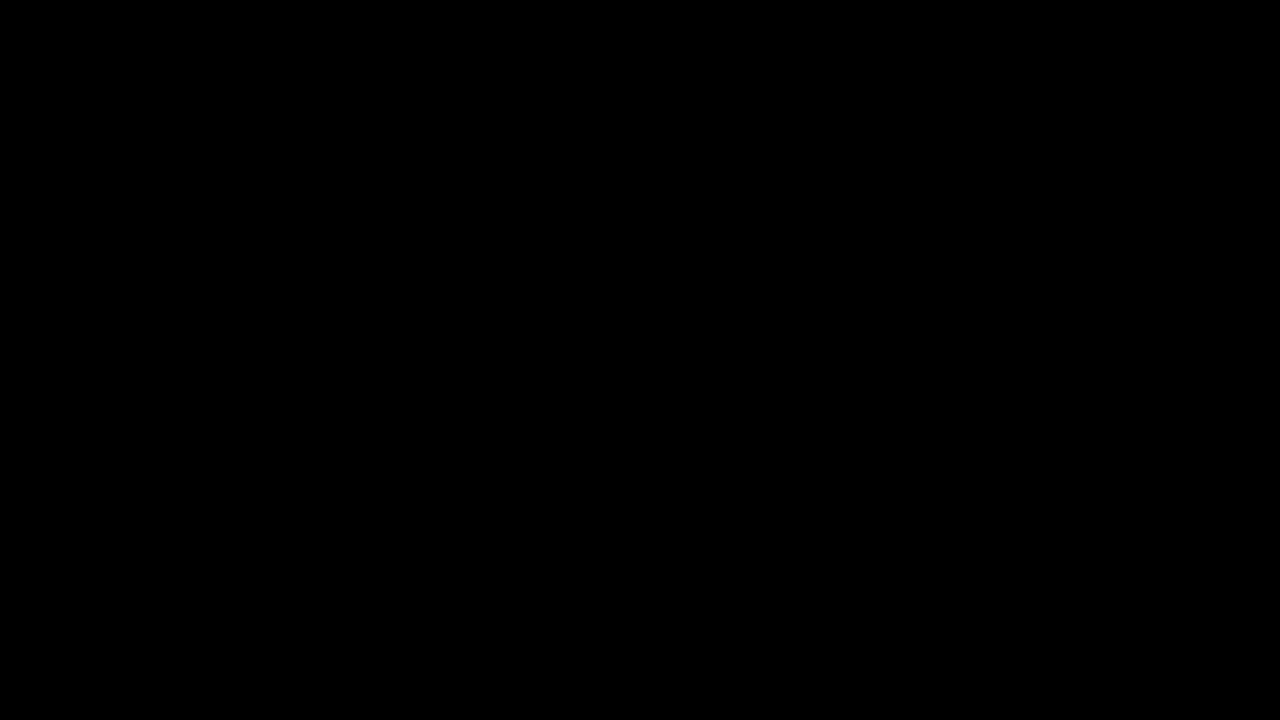

In [ ]:
%%manim -qm -v WARNING ConditionalProbVenn


class ConditionalProbVenn(Scene):
    """Show P(A|B) as shrinking the sample space to B."""

    def construct(self):
        # Sample space rectangle
        omega_rect = Rectangle(width=8, height=4.5, color=WHITE, stroke_width=2)
        omega_label = math_text(r"\Omega", font_size=24).move_to(
            omega_rect.get_corner(UL) + DR * 0.3
        )

        # Events as circles
        circle_a = Circle(
            radius=1.3, color=C.SALMON, fill_opacity=0.25, stroke_width=2.5
        )
        circle_a.shift(LEFT * 0.7)
        label_a = math_text(r"A", font_size=28, color=C.SALMON).next_to(
            circle_a, UL, buff=0.1
        )

        circle_b = Circle(
            radius=1.3, color=C.PERIWINKLE, fill_opacity=0.25, stroke_width=2.5
        )
        circle_b.shift(RIGHT * 0.7)
        label_b = math_text(r"B", font_size=28, color=C.PERIWINKLE).next_to(
            circle_b, UR, buff=0.1
        )

        # Intersection
        intersection = Intersection(
            circle_a, circle_b, color=C.ORCHID, fill_opacity=0.4, stroke_width=0
        )
        int_label = math_text(r"A \cap B", font_size=20, color=C.ORCHID).move_to(ORIGIN)

        title1 = Text("Full sample space Ω", font_size=26).to_edge(UP)

        self.play(
            Create(omega_rect),
            Write(omega_label),
            Create(circle_a),
            Write(label_a),
            Create(circle_b),
            Write(label_b),
            FadeIn(intersection),
            Write(int_label),
            Write(title1),
            run_time=1.5,
        )
        self.wait(1)

        # Show the formula
        formula = math_text(
            r"P(A|B) = \frac{P(A \cap B)}{P(B)}", font_size=30, color=C.GOLD
        ).to_edge(DOWN)
        self.play(Write(formula))
        self.wait(1)

        # Now "shrink" — fade out everything outside B
        title2 = Text(
            "Condition on B: new universe is B", font_size=26, color=C.PERIWINKLE
        ).to_edge(UP)
        self.play(
            omega_rect.animate.set_opacity(0.1),
            omega_label.animate.set_opacity(0.2),
            circle_a.animate.set_fill(opacity=0.05),
            label_a.animate.set_opacity(0.3),
            circle_b.animate.set_fill(opacity=0.35).set_stroke(width=4),
            intersection.animate.set_fill(opacity=0.6),
            Transform(title1, title2),
            run_time=1.5,
        )

        # Highlight: P(A|B) = the bright part / all of B
        brace = Brace(circle_b, DOWN, color=C.PERIWINKLE)
        brace_txt = math_text(
            r"P(B) = 1\ (\text{new universe})", font_size=20, color=C.PERIWINKLE
        )
        brace_txt.next_to(brace, DOWN, buff=0.1)
        self.play(GrowFromCenter(brace), Write(brace_txt), run_time=0.8)
        self.wait(2)

When we condition on $B$, everything outside $B$ fades away. $B$ becomes the new universe (probability 1), and $P(A|B)$ is the fraction of $B$ occupied by the intersection $A \cap B$.

---

## 2. The Multiplication Rule

Rearranging the definition of conditional probability gives the **multiplication rule** for joint probabilities:

> **Theorem 3.2 (Multiplication rule).** For any events $A$ and $B$:
>
> $$P(A \cap B) = P(B) \cdot P(A \mid B) = P(A) \cdot P(B \mid A)$$

This extends to chains of events:

$$P(A_1 \cap A_2 \cap A_3) = P(A_1) \cdot P(A_2 \mid A_1) \cdot P(A_3 \mid A_1 \cap A_2)$$

### Example: drawing cards without replacement

Draw 2 cards from a deck. What is $P(\text{both are Aces})$?

$$P(A_1 \cap A_2) = P(A_1) \cdot P(A_2 \mid A_1) = \frac{4}{52} \cdot \frac{3}{51} = \frac{12}{2652} = \frac{1}{221} \approx 0.00452$$

In [ ]:
# Analytical
p_both_aces = (4 / 52) * (3 / 51)
print(f"P(both Aces) = (4/52) × (3/51) = {p_both_aces:.6f} ≈ 1/{1 / p_both_aces:.0f}")

# Simulation
rng = np.random.default_rng(42)
n_sims = 500_000
deck = np.arange(52)  # 0-3 are Aces
both_aces = 0

for _ in range(n_sims):
    draw = rng.choice(deck, size=2, replace=False)
    if draw[0] < 4 and draw[1] < 4:
        both_aces += 1

print(f"Simulated:     {both_aces / n_sims:.6f}  (n = {n_sims:,})")

P(both Aces) = (4/52) × (3/51) = 0.004525 ≈ 1/221
Simulated:     0.004606  (n = 500,000)


---

## 3. Independence

Sometimes learning that $B$ occurred tells us **nothing** about $A$. In that case $P(A|B) = P(A)$, and we say the events are independent.

> **Definition 3.3 (Independence).** Events $A$ and $B$ are *independent* if and only if
>
> $$P(A \cap B) = P(A) \cdot P(B)$$
>
> Equivalently (when $P(B) > 0$): $P(A \mid B) = P(A)$.

**Important:** Independence is a mathematical property, not a physical one. Two events can be physically unrelated yet dependent (because they share outcomes), or physically related yet independent.

### Example: cards (independent)

"Card is an Ace" and "Card is a heart" are independent:
- $P(\text{Ace}) = 4/52 = 1/13$
- $P(\text{heart}) = 13/52 = 1/4$
- $P(\text{Ace} \cap \text{heart}) = 1/52 = \frac{1}{13} \cdot \frac{1}{4}$ ✓

### Example: dice (not independent)

Roll one die. "Roll ≤ 3" and "Roll is even" are **not** independent:
- $P(\leq 3) = 3/6 = 1/2$
- $P(\text{even}) = 3/6 = 1/2$
- $P(\leq 3 \cap \text{even}) = P(\{2\}) = 1/6 \neq 1/2 \cdot 1/2 = 1/4$ ✗

In [ ]:
# Test independence programmatically
def test_independence(omega, A, B, names=("A", "B")):
    """Check if events A and B are independent over sample space omega."""
    n = len(omega)
    p_a = len(A) / n
    p_b = len(B) / n
    p_ab = len(A & B) / n
    product = p_a * p_b
    independent = abs(p_ab - product) < 1e-10

    print(f"P({names[0]}) = {p_a:.4f}")
    print(f"P({names[1]}) = {p_b:.4f}")
    print(f"P({names[0]} ∩ {names[1]}) = {p_ab:.4f}")
    print(f"P({names[0]}) × P({names[1]}) = {product:.4f}")
    print(f"Independent? {'Yes ✓' if independent else 'No ✗'}\n")


# Die example
omega_die = set(range(1, 7))
test_independence(omega_die, {1, 2, 3}, {2, 4, 6}, ("≤3", "even"))

# Card example (encode as (rank, suit) tuples)
omega_cards = {(r, s) for r in range(13) for s in range(4)}
aces = {(0, s) for s in range(4)}  # rank 0 = Ace
hearts = {(r, 0) for r in range(13)}  # suit 0 = hearts
test_independence(omega_cards, aces, hearts, ("Ace", "Heart"))

P(≤3) = 0.5000
P(even) = 0.5000
P(≤3 ∩ even) = 0.1667
P(≤3) × P(even) = 0.2500
Independent? No ✗

P(Ace) = 0.0769
P(Heart) = 0.2500
P(Ace ∩ Heart) = 0.0192
P(Ace) × P(Heart) = 0.0192
Independent? Yes ✓



---

## 4. Bayes' Theorem

Conditional probability is **asymmetric**: $P(A|B) \neq P(B|A)$ in general. Bayes' theorem tells us how to **invert** a conditional probability:

> **Theorem 3.4 (Bayes' theorem).** For events $A$ and $B$ with $P(B) > 0$:
>
> $$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

**Proof.** By the multiplication rule: $P(A \cap B) = P(B|A) \cdot P(A) = P(A|B) \cdot P(B)$. Divide both sides by $P(B)$. $\square$

The terms have standard names (especially in Bayesian statistics, which we cover in Module 07):

| Term          | Name                    | Meaning                                          |
|---------------|-------------------------|--------------------------------------------------|
| $P(A)$        | **Prior**               | What we believed about $A$ before seeing $B$     |
| $P(B \mid A)$ | **Likelihood**          | How probable is the evidence $B$ if $A$ is true? |
| $P(B)$        | **Marginal likelihood** | Total probability of observing $B$               |
| $P(A \mid B)$ | **Posterior**           | Updated belief about $A$ after seeing $B$        |

### Example: medical screening (the base-rate fallacy)

This is one of the most important applications of Bayes' theorem and a frequent source of misunderstanding — both in everyday life and in medicine.

A disease affects **1%** of the population. A screening test has:
- **Sensitivity** (true positive rate): $P(+|\text{disease}) = 0.80$
- **False positive rate**: $P(+|\text{no disease}) = 0.096$

You test positive. What is $P(\text{disease}|+)$?

Most people guess around 80%. The correct answer is strikingly lower:

$$P(D|+) = \frac{P(+|D) \cdot P(D)}{P(+|D) \cdot P(D) + P(+|\bar{D}) \cdot P(\bar{D})} = \frac{0.80 \times 0.01}{0.80 \times 0.01 + 0.096 \times 0.99}$$

In [ ]:
# Bayes' theorem: medical screening
p_disease = 0.01
p_pos_given_disease = 0.80  # sensitivity
p_pos_given_healthy = 0.096  # false positive rate

# P(+) via law of total probability (we'll formalise this in the next notebook)
p_pos = p_pos_given_disease * p_disease + p_pos_given_healthy * (1 - p_disease)

# Bayes' theorem
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print(f"P(disease)         = {p_disease}")
print(f"P(+|disease)       = {p_pos_given_disease}")
print(f"P(+|healthy)       = {p_pos_given_healthy}")
print(f"P(+)               = {p_pos:.5f}")
print(f"\nP(disease|+)       = {p_disease_given_pos:.4f}")
print(f"\nOnly {p_disease_given_pos:.1%} of positive tests are true positives!")

P(disease)         = 0.01
P(+|disease)       = 0.8
P(+|healthy)       = 0.096
P(+)               = 0.10304

P(disease|+)       = 0.0776

Only 7.8% of positive tests are true positives!


**Why so low?** Because the disease is rare (1%). Even with a good test, the vast majority of the population is healthy, and even a small false-positive rate on that large group produces many false alarms. This is the **base-rate fallacy** — ignoring the prior $P(D) = 0.01$ and focusing only on the test accuracy.

The plot below makes this concrete by showing what happens in a population of 10,000 people:

Population:       10,000
  Have disease:   100 → 80 test +, 20 test −
  Healthy:        9,900 → 950 test +, 8,950 test −

Total positive tests: 1030
  Of those, truly sick: 80 = 7.8%


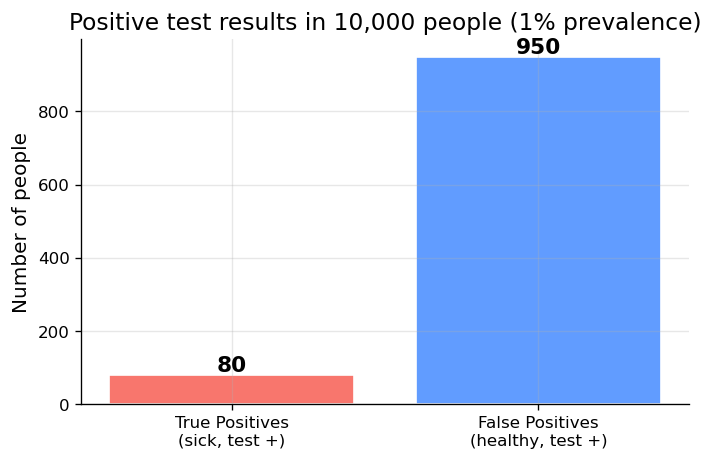

In [ ]:
# Natural frequencies: what happens in 10,000 people?
n_pop = 10_000
n_disease = int(n_pop * p_disease)
n_healthy = n_pop - n_disease

true_pos = int(n_disease * p_pos_given_disease)
false_neg = n_disease - true_pos
false_pos = int(n_healthy * p_pos_given_healthy)
true_neg = n_healthy - false_pos

print(f"Population:       {n_pop:,}")
print(f"  Have disease:   {n_disease} → {true_pos} test +, {false_neg} test −")
print(f"  Healthy:        {n_healthy:,} → {false_pos} test +, {true_neg:,} test −")
print(f"\nTotal positive tests: {true_pos + false_pos}")
print(f"  Of those, truly sick: {true_pos} = {true_pos / (true_pos + false_pos):.1%}")

# Visualise as a bar chart
fig, ax = plt.subplots(figsize=(6, 4))
categories = ["True Positives\n(sick, test +)", "False Positives\n(healthy, test +)"]
counts = [true_pos, false_pos]
bars = ax.bar(categories, counts, color=["#F8766D", "#619CFF"], edgecolor="white")
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count),
        ha="center",
        fontsize=13,
        fontweight="bold",
    )
ax.set_ylabel("Number of people")
ax.set_title(f"Positive test results in {n_pop:,} people (1% prevalence)")
plt.tight_layout()
plt.show()

Out of roughly 958 positive tests, only 8 have the disease. The false positives vastly outnumber the true positives — all because the base rate is so low.

### The asymmetry of conditional probability

This example also illustrates a critical point: $P(A|B) \neq P(B|A)$.

- $P(+|\text{disease}) = 0.80$ (the test is quite good at detecting the disease)
- $P(\text{disease}|+) = 0.078$ (but a positive test barely tells you anything)

Confusing these two is called the **prosecutor's fallacy** in legal contexts and the **confusion of the inverse** in statistics.

---

## 5. Worked Example: Sequential Card Draws

Let's combine everything. Draw 3 cards from a deck without replacement. What is $P(\text{all 3 are hearts})$?

**Using the multiplication rule:**

$$P(H_1 \cap H_2 \cap H_3) = P(H_1) \cdot P(H_2 | H_1) \cdot P(H_3 | H_1 \cap H_2) = \frac{13}{52} \cdot \frac{12}{51} \cdot \frac{11}{50}$$

**Using combinations (from the previous notebook):**

$$P = \frac{\binom{13}{3}}{\binom{52}{3}}$$

Both approaches must give the same answer:

In [ ]:
from math import comb

# Multiplication rule
p_mult = (13 / 52) * (12 / 51) * (11 / 50)

# Combinations
p_comb = comb(13, 3) / comb(52, 3)

print(f"Multiplication rule: {p_mult:.6f}")
print(f"Combinations:        {p_comb:.6f}")
print(f"Match: {abs(p_mult - p_comb) < 1e-12}")

# Simulation
n_sims = 500_000
deck = np.arange(52)
count = sum(
    1 for _ in range(n_sims) if all(c < 13 for c in rng.choice(deck, 3, replace=False))
)
print(f"Simulated:           {count / n_sims:.6f}")

Multiplication rule: 0.012941
Combinations:        0.012941
Match: True
Simulated:           0.012840


---

## Exercises

**Exercise 3.1 (Conditional probability).** Roll two dice. Compute $P(\text{sum} = 6 \mid \text{at least one die is 2})$. Verify by enumeration.

**Exercise 3.2 (Independence).** A fair coin is flipped twice. Are the events "first flip is H" and "both flips are the same" independent? Prove or disprove using the definition.

**Exercise 3.3 (Bayes — drug test).** A drug test is 99% accurate (both sensitivity and specificity). If 0.5% of the population uses the drug, what is $P(\text{user} | +)$?

**Exercise 3.4 (Multiplication rule).** A bag has 5 red and 3 blue balls. You draw 2 without replacement. What is $P(\text{both red})$? $P(\text{one of each color})$?

**Exercise 3.5 (Monty Hall — Challenge).** Behind 3 doors: 1 car, 2 goats. You pick a door, the host opens another door revealing a goat, and offers you the chance to switch.
- Use conditional probability to show that switching wins with probability $2/3$.
- Write a simulation to verify.

**Exercise 3.6 (Sequential Bayes).** In the medical screening example, suppose a person tests positive and then takes a *second* independent test, which is also positive. Now what is $P(\text{disease})$? (*Hint:* use the posterior from the first test as the prior for the second.)

---

## Key Takeaways

1. **Conditional probability** $P(A|B) = P(A \cap B) / P(B)$ — learning that $B$ occurred shrinks the sample space to $B$.
2. The **multiplication rule** $P(A \cap B) = P(A) \cdot P(B|A)$ lets us compute joint probabilities step by step.
3. **Independence** means $P(A \cap B) = P(A) \cdot P(B)$ — knowing about one event tells us nothing about the other.
4. **Bayes' theorem** inverts conditional probabilities: $P(A|B) = P(B|A) \cdot P(A) / P(B)$.
5. The **base-rate fallacy** — ignoring prior probabilities — leads to dramatic errors in interpreting diagnostic tests.
6. $P(A|B) \neq P(B|A)$ in general. Always be clear about which direction the conditioning goes.

**Next:** [04_law_of_total_probability.ipynb](04_law_of_total_probability.ipynb) — The law of total probability, partitions, and the full machinery for computing $P(B)$ in Bayes' theorem.

In [11]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-05-35.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-10-14.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@13-42-51.gif
  ✓ media/gifs/ConditionalProbVenn@2026-03-19@13-48-05.gif
  ✓ media/gifs/DiceHistogram@2026-03-19@13-43-26.gif
  ✓ media/gifs/PascalTriangle@2026-03-19@13-44-25.gif
  ✓ media/gifs/TreeDiagram@2026-03-19@13-44-07.gif
  ✓ media/gifs/ConditionalProbVenn_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
